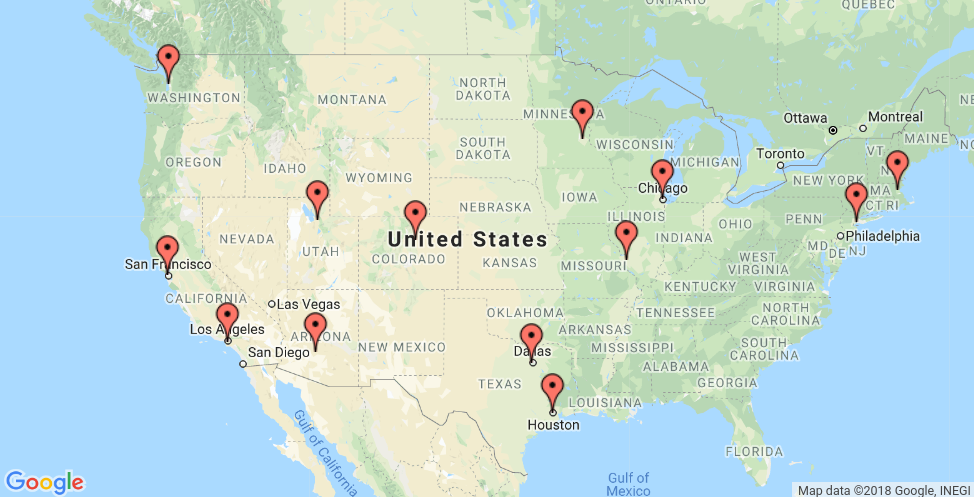

0. New York 
1. Los Angeles 
2. Chicago 
3. Minneapolis 
4. Denver 
5. Dallas 
6. Seattle 
7. Boston 
8. San Francisco 
9. St. Louis 
10. Houston 
11. Phoenix 
12. Salt Lake City

In [6]:
from ortools.constraint_solver import routing_enums_pb2, pywrapcp

In [7]:
# data model
def create_data_model():
    data = {}
    data["distance_matrix"] = [
        [0, 2451, 713, 1018, 1631, 1374, 2408, 213, 2571, 875, 1420, 2145, 1972],
        [2451, 0, 1745, 1524, 831, 1240, 959, 2596, 403, 1589, 1374, 357, 579],
        [713, 1745, 0, 355, 920, 803, 1737, 851, 1858, 262, 940, 1453, 1260],
        [1018, 1524, 355, 0, 700, 862, 1395, 1123, 1584, 466, 1056, 1280, 987],
        [1631, 831, 920, 700, 0, 663, 1021, 1769, 949, 796, 879, 586, 371],
        [1374, 1240, 803, 862, 663, 0, 1681, 1551, 1765, 547, 225, 887, 999],
        [2408, 959, 1737, 1395, 1021, 1681, 0, 2493, 678, 1724, 1891, 1114, 701],
        [213, 2596, 851, 1123, 1769, 1551, 2493, 0, 2699, 1038, 1605, 2300, 2099],
        [2571, 403, 1858, 1584, 949, 1765, 678, 2699, 0, 1744, 1645, 653, 600],
        [875, 1589, 262, 466, 796, 547, 1724, 1038, 1744, 0, 679, 1272, 1162],
        [1420, 1374, 940, 1056, 879, 225, 1891, 1605, 1645, 679, 0, 1017, 1200],
        [2145, 357, 1453, 1280, 586, 887, 1114, 2300, 653, 1272, 1017, 0, 504],
        [1972, 579, 1260, 987, 371, 999, 701, 2099, 600, 1162, 1200, 504, 0],
    ]
    data["num_vehicles"] = 1
    data["depot"] = 0
    return data

In [8]:
# prints the derived solution
def print_solution(manager, routing, solution):
    print(f"Objective: {solution.ObjectiveValue()} miles")
    index = routing.Start(0)
    plan_output = "Route for Vehicle 0:\n"
    route_distance = 0
    while not routing.IsEnd(index):
        plan_output += f" {manager.IndexToNode(index)} -> "
        previous_index = index
        index = solution.Value(routing.NextVar(index))
        route_distance = routing.GetArcCostForVehicle(previous_index, index, 0)
    plan_output += f" {manager.IndexToNode(index)}\n"
    plan_output += f"Route Distance: {route_distance} miles\n"
    print(plan_output)

In [9]:
# save routes to an array
def save_routes(solution, manager, routing):
    routes = []
    for route_nbr in range(routing.vehicles()):
        index = routing.Start(route_nbr)
        route = [manager.IndexToNode(index)]
        while not routing.IsEnd(index):
            index = solution.Value(routing.NextVar(index))
            route.append(manager.IndexToNode(index))
        routes.append(route)
    return routes

In [ ]:
# create the data model
data = create_data_model()
# create the routing index manager
manager = pywrapcp.RoutingIndexManager(
    len(data["distance_matrix"]), data["num_vehicles"], data["depot"]
)
# create the routing model
routing = pywrapcp.RoutingModel(manager)
# function - to get the distance between two nodes
def distance_callback(from_index, to_index):
    # convert routing variable index to distance matrix node
        # routing variable index is how the manager saves the locations each time
        # uses IndexToNode function of manager to get correct node
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data["distance_matrix"][from_node][to_node]
# register above function as the function to calculate cost, in other words -> Length
transit_callback_index = routing.RegisterTransitCallback(distance_callback)
# use the registered function to calculate cost
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)
# add the search parameters
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
# first solution -> put smallest distance arc from depot and continue along
search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)
# solving
solution = routing.SolveWithParameters(search_parameters)
# print the solution, if there is any
if solution:
    print_solution(manager, routing, solution)
    routes = save_routes(solution, manager, routing)   
    for idx, route in enumerate(routes):
        print("Route", idx, route)    